In [ ]:
!pip install -q torchvision pillow

import io, random
import numpy as np
from PIL import Image, ImageFilter, ImageEnhance
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torchvision.models import resnet18
from google.colab import files

In [ ]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
TARGET_SIZE = 299
RESIZE_SIZE = 320

print("Using device:", DEVICE)

Using device: cpu


In [ ]:
def center_crop_resize(img: Image.Image) -> Image.Image:
    img = img.convert("RGB")
    img = img.resize((RESIZE_SIZE, RESIZE_SIZE), Image.BICUBIC)
    left = (RESIZE_SIZE - TARGET_SIZE) // 2
    return img.crop((left, left, left + TARGET_SIZE, left + TARGET_SIZE))

def fft_transform(img_tensor: torch.Tensor) -> torch.Tensor:
    # img_tensor: (3,H,W) in [0,1]
    gray = img_tensor.mean(dim=0, keepdim=True)  # (1,H,W)
    fft = torch.fft.fftshift(torch.fft.fft2(gray))
    mag = torch.log1p(torch.abs(fft))
    mag = (mag - mag.min()) / (mag.max() - mag.min() + 1e-8)  # <-- IMPORTANT (min-max to [0,1])
    return mag.repeat(3, 1, 1)  # (3,H,W)

def preprocess_for_inference(pil_img: Image.Image) -> torch.Tensor:
    img = center_crop_resize(pil_img)
    x = torch.from_numpy(np.array(img)).permute(2,0,1).float() / 255.0  # (3,H,W)
    x = fft_transform(x)  # (3,H,W) in [0,1]
    return x

In [ ]:
uploaded = files.upload()
ckpt_path = list(uploaded.keys())[0]

ckpt = torch.load(ckpt_path, map_location=DEVICE)

model = resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, 2)

# load only model weights
model.load_state_dict(ckpt["model_state_dict"] if "model_state_dict" in ckpt else ckpt)

model.to(DEVICE)
model.eval()

print("✅ Loaded model from:", ckpt_path)

Saving latest_resnet18_fft_sourceaware.pth to latest_resnet18_fft_sourceaware.pth
✅ Loaded model from: latest_resnet18_fft_sourceaware.pth


Saving fake_041595.jpg to fake_041595.jpg
Saving fake_041608.jpg to fake_041608 (1).jpg
Saving gpt.jpeg to gpt (1).jpeg

fake_041595.jpg
logits: [[-3.9241166  4.029397 ]]
probs : [3.5130174e-04 9.9964869e-01] -> FAKE (conf=0.9996)


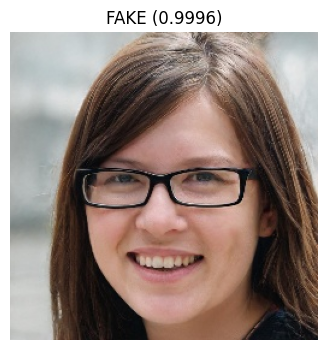


fake_041608 (1).jpg
logits: [[-7.250307  7.501335]]
probs : [3.9214169e-07 9.9999964e-01] -> FAKE (conf=1.0000)


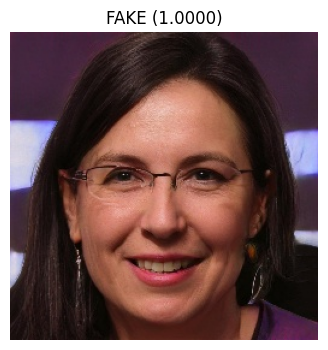


gpt (1).jpeg
logits: [[ 2.4501004 -2.2957828]]
probs : [0.9913874  0.00861257] -> REAL (conf=0.9914)


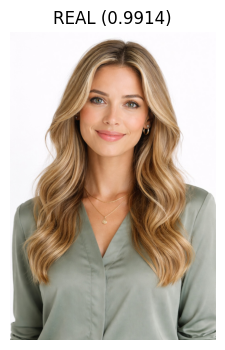

In [ ]:
def predict_pil(pil_img: Image.Image):
    x = preprocess_for_inference(pil_img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(logits, dim=1)[0].cpu().numpy()

    pred = int(np.argmax(probs))
    conf = float(probs[pred])
    label = "FAKE" if pred == 1 else "REAL"

    return label, conf, probs, logits.cpu().numpy()

uploaded_imgs = files.upload()

for name in uploaded_imgs.keys():
    pil_img = Image.open(io.BytesIO(uploaded_imgs[name])).convert("RGB")
    label, conf, probs, logits = predict_pil(pil_img)

    print(f"\n{name}")
    print("logits:", logits)
    print("probs :", probs, "->", label, f"(conf={conf:.4f})")

    plt.figure(figsize=(4,4))
    plt.imshow(pil_img)
    plt.title(f"{label} ({conf:.4f})")
    plt.axis("off")
    plt.show()